In [1]:
# !git clone https://github.com/Kemsekov/kemsekov_torch

In [2]:
import numpy as np
import pandas as pd
import torch

# age, height, weight dataset
data_csv = (pd.read_csv("data.csv"))
data_csv = data_csv.drop(columns=data_csv.columns[:2])

data_mean = data_csv.mean()
data_std = data_csv.std()
normalized_data = (data_csv-data_mean)/data_std
normalized_data=torch.tensor(normalized_data.to_numpy()).float()

data_mean=torch.tensor(data_mean.to_numpy())
data_std=torch.tensor(data_std.to_numpy())

In [3]:
data_csv

,age,weight,height
0,2,13.7,88.6
1,2,13.9,94.2
2,66,79.5,158.3
3,18,66.3,175.7
4,13,45.4,158.4
...,...,...,...
8000,70,49.0,156.5
8001,42,97.4,164.9
8002,41,69.1,162.6
8003,14,111.9,156.6


In [4]:
data = normalized_data
data.shape

torch.Size([8005, 3])

In [5]:
import math
from kemsekov_torch.invertible_nn import SmoothSymmetricSqrt, KFunction
from kemsekov_torch.normalizing_flow import NormalizingFlow
from kemsekov_torch.flow_matching import FlowModel1d
torch.manual_seed(2)

fm = FlowModel1d(
    data.shape[-1],
    hidden_dim=64,
    residual_blocks=5,
    device='cuda'
)
with torch.no_grad():
    print("logprob before train",fm.log_prob(data).mean())
fm.fit(data,batch_size=512,epochs=64,debug=True,contrastive_loss_weight=0.1)
with torch.no_grad():
    print("logprob after train",fm.log_prob(data).mean())

logprob before train tensor(-5.5637, device='cuda:0')
Epoch 1: best_loss=3.244	best r2=0.029
Epoch 2: best_loss=2.571	best r2=0.317
Epoch 3: best_loss=2.518	best r2=0.360
Epoch 5: best_loss=2.473	best r2=0.375
Epoch 8: best_loss=2.460	best r2=0.380
Epoch 9: best_loss=2.412	best r2=0.405
Epoch 28: best_loss=2.402	best r2=0.406
Epoch 30: best_loss=2.378	best r2=0.415
Epoch 47: best_loss=2.369	best r2=0.423
logprob after train tensor(-2.2125, device='cuda:0')


Text(0, 0.5, 'R2')

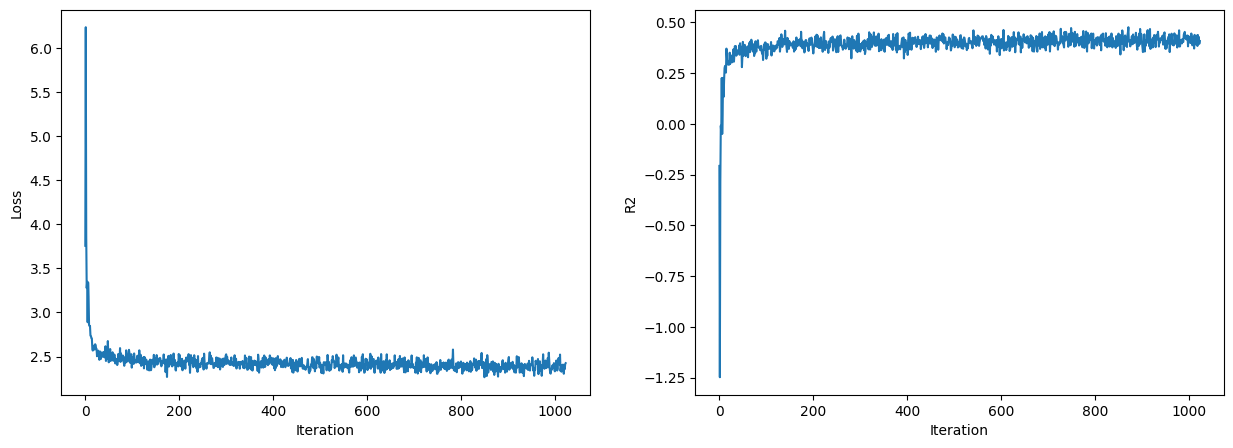

In [6]:
from matplotlib import pyplot as plt

fig,ax = plt.subplots(ncols=2,figsize=(15,5))
ax[0].plot(fm.fit_history['loss'])
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Loss")

ax[1].plot(fm.fit_history['r2'])
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("R2")

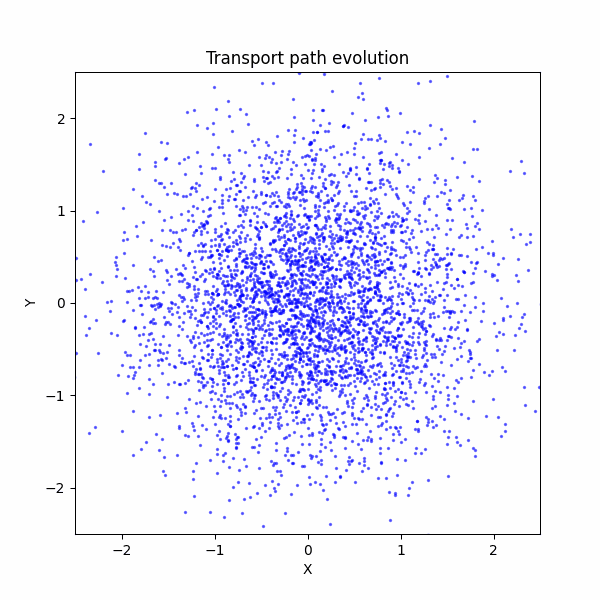

In [7]:
import matplotlib.animation as animation
from IPython.display import Image, display

with torch.no_grad():
    normal_noise = torch.randn((4096,3))
    a,b = fm.fm.integrate(fm,normal_noise.to(fm.device),steps=32,return_intermediates=True)
    a = a.cpu()
    b=[i.cpu() for i in b]
fig, ax = plt.subplots(figsize=(6, 6))

# Initialize scatter plot
scatter = ax.scatter([], [], s=2, alpha=0.5, c='blue')

# Set axis limits (adjust based on your data range)
ax.set_xlim(-2.5, 2.5)  # Adjust based on your data
ax.set_ylim(-2.5, 2.5)  # Adjust based on your data
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Transport path evolution')

# Animation update function
def update(frame):
    data = b[frame][:,[0,1]]
    scatter.set_offsets(data)
    # ax.set_title(f'Animation Frame {frame + 1}/{len(b)}')
    return scatter,

# Create animation
ani = animation.FuncAnimation(
    fig, 
    update, 
    frames=len(b), 
    interval=100,  # milliseconds between frames
    blit=True
)

# Save as GIF
ani.save('animation.gif', writer='pillow', fps=10)

# Display in notebook
plt.close(fig)  # Close the static figure

display(Image(filename="animation.gif"))

In [14]:
from copy import deepcopy

fm_reflow = deepcopy(fm)
torch.manual_seed(0)
fm_reflow.reflow(data,epochs=1024)

with torch.no_grad():
    print("logprob after reflow",fm_reflow.log_prob(data).mean())

logprob after reflow tensor(-2.2039, device='cuda:0')


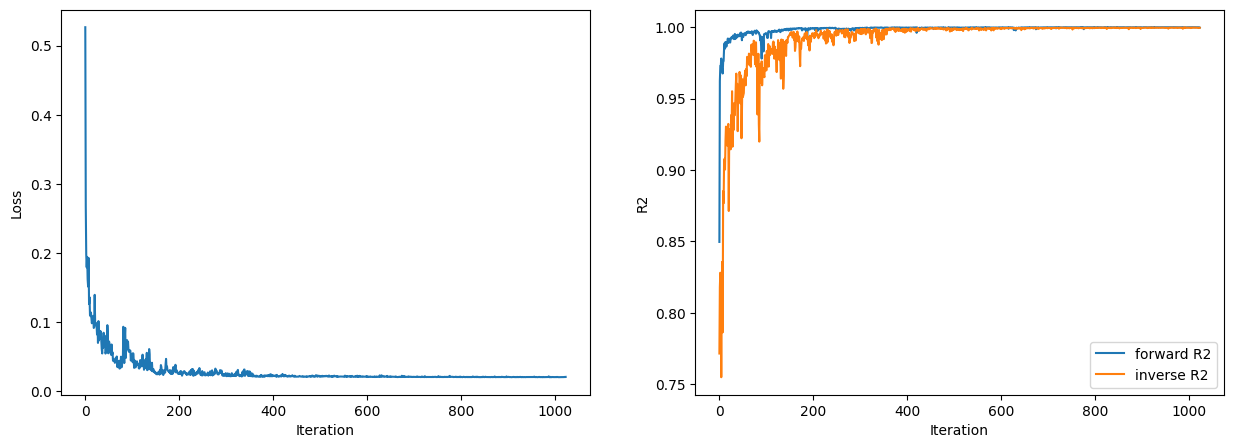

In [15]:
fig,ax = plt.subplots(ncols=2,figsize=(15,5))
ax[0].plot(fm_reflow.reflow_history['loss'])
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Loss")

ax[1].plot(fm_reflow.reflow_history['forward_r2'],label='forward R2')
ax[1].plot(fm_reflow.reflow_history['inverse_r2'],label='inverse R2')
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("R2")
ax[1].legend()

MMD^2 0.0001


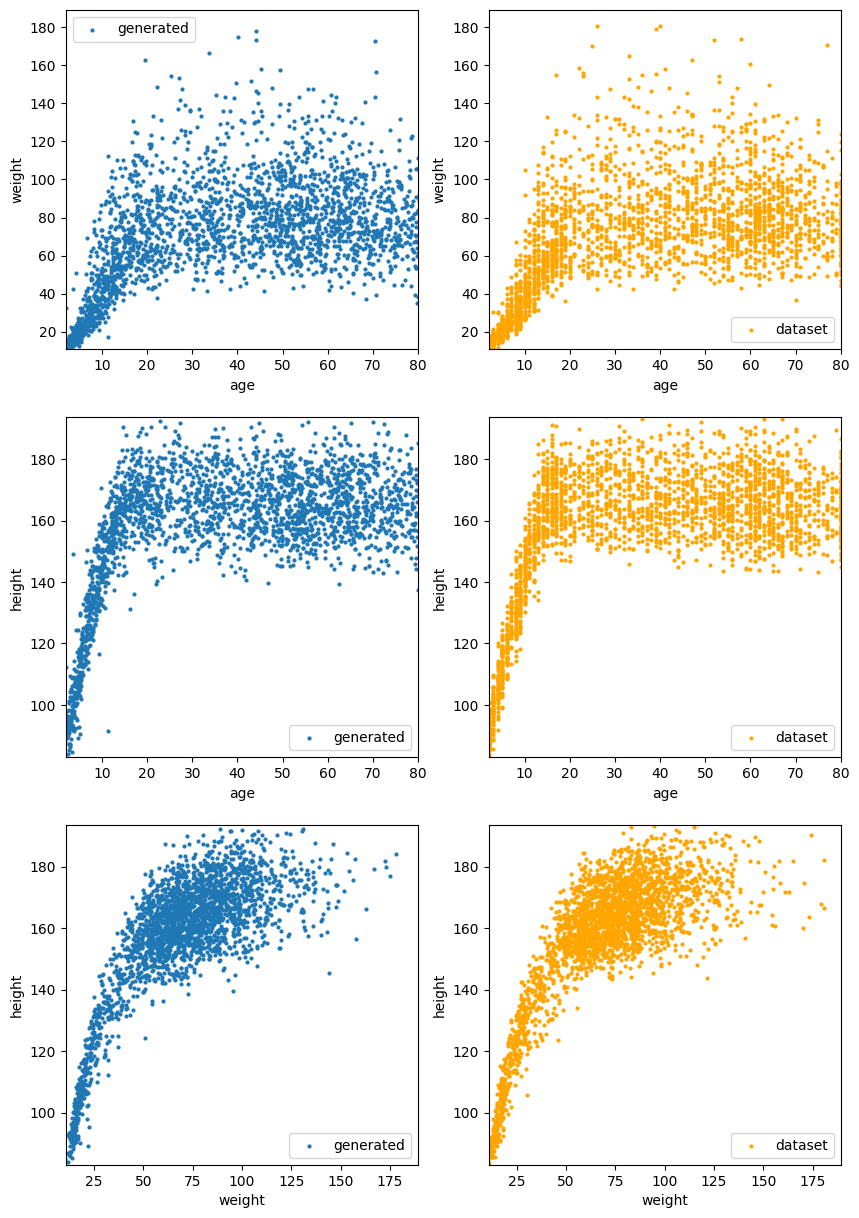

In [16]:
from matplotlib import pyplot as plt
import numpy as np
from kemsekov_torch.common_modules import mmd_rbf

cols = data_csv.columns

n=2500
data_sample = data_csv.sample(n=n).to_numpy()
cond = data[[50]]

with torch.no_grad():
    random_sample = fm_reflow.sample(n).cpu()
    
model_sample=(random_sample*data_std+data_mean)

permutations = [
    [0,1],
    [0,2],
    [1,2]
]

plt.figure(figsize=(10,15))
for i,(indA,indB) in enumerate(permutations):
    X,Y=data_sample[:,indA],data_sample[:,indB]
    X_lim = np.quantile(X,0.001),np.quantile(X,0.999)
    Y_lim = np.quantile(Y,0.001),np.quantile(Y,0.999)
    plt.subplot(3,2,2*i+1)
    plt.scatter(model_sample[:,indA],model_sample[:,indB],s=4,label="generated")
    plt.xlim(*X_lim)
    plt.ylim(*Y_lim)
    plt.xlabel(cols[indA])
    plt.ylabel(cols[indB])
    plt.legend()
    
    plt.subplot(3,2,2*i+2)
    plt.scatter(X,Y,s=4,label="dataset",c='orange')
    plt.xlim(*X_lim)
    plt.ylim(*Y_lim)
    plt.xlabel(cols[indA])
    plt.ylabel(cols[indB])
    plt.legend()
    
distrib_distance = mmd_rbf(data_sample,model_sample)[0]
print(f"MMD^2 {distrib_distance:0.4f}")

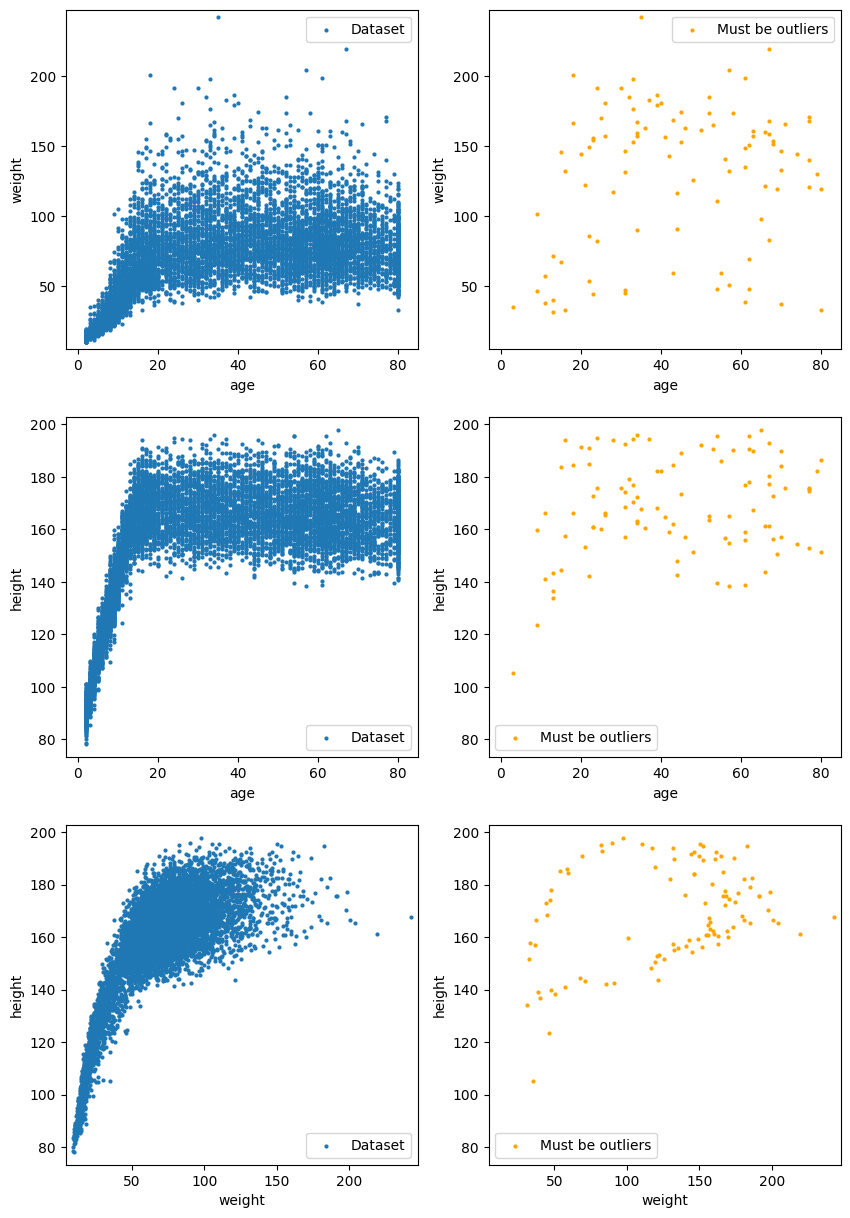

In [17]:
from torch.distributions import Normal
with torch.no_grad():
    probs = fm_reflow.log_prob(data).exp().argsort().cpu()

mask = probs[:100]
data_numpy = data_csv.to_numpy()

plt.figure(figsize=(10,15))
for i,(indA,indB) in enumerate(permutations):
    X,Y=data_numpy[:,indA],data_numpy[:,indB]
    X_lim = np.quantile(X,0)-5,np.quantile(X,1)+5
    Y_lim = np.quantile(Y,0)-5,np.quantile(Y,1)+5
    plt.subplot(3,2,2*i+1)
    plt.scatter(X,Y,s=4,label="Dataset")
    plt.xlim(*X_lim)
    plt.ylim(*Y_lim)
    plt.xlabel(cols[indA])
    plt.ylabel(cols[indB])
    plt.legend()
    
    plt.subplot(3,2,2*i+2)
    plt.scatter(X[mask],Y[mask],s=4,label="Must be outliers",c='orange')
    plt.xlim(*X_lim)
    plt.ylim(*Y_lim)
    plt.xlabel(cols[indA])
    plt.ylabel(cols[indB])
    plt.legend()

In [12]:
# list of outliers
data_csv.iloc[probs[:20]]

,age,weight,height
3671,35,242.6,167.8
7848,67,219.6,161.3
6907,13,49.5,146.0
5535,18,200.9,166.4
365,57,204.4,165.3
4895,37,183.0,194.6
2636,61,198.7,177.1
3421,32,43.6,146.8
3453,77,170.8,174.7
1765,14,43.2,147.2


Text(0.5, 1.0, 'Weight/height learned Probability visualization')

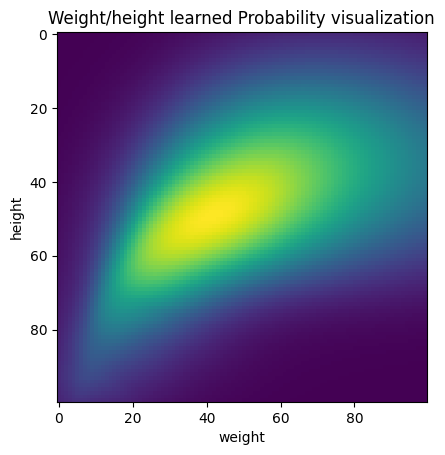

In [19]:
X = torch.linspace(-2.5,2.5,8)
Y = torch.linspace(-2,2.5,100)
Z = torch.linspace(2.5,-2.5,100)

grid = torch.stack(torch.meshgrid([X,Y,Z],indexing="ij"),-1)
with torch.no_grad():
    probs = fm_reflow.log_prob(grid.view(-1,3),random_directions=2).view(grid.shape[:-1]).cpu()
xy_probs = probs.mean(0)
plt.imshow((xy_probs.T/4).exp())
plt.xlabel("weight")
plt.ylabel("height")
plt.title("Weight/height learned Probability visualization")

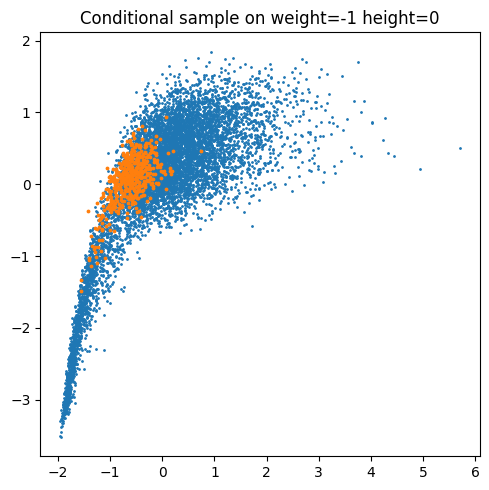

In [21]:
weight = -1
height = 0
def constraint(x):
    a = ((x[:,1]-weight)**2).mean()
    b = ((x[:,2]-height)**2).mean()
    return a+b

constrained_samples = fm_reflow.constrained_sample(
    constraint=constraint,
    num_samples=500,
    noise_scale=0.2,
    steps=2,
    mode_closeness_weight=0
).cpu()

plt.figure(figsize=(5,5))
plt.scatter(data[:,1],data[:,2],s=1)
plt.scatter(constrained_samples[:,1],constrained_samples[:,2],s=3)
plt.title(f"Conditional sample on weight={weight} height={height}")
plt.tight_layout()

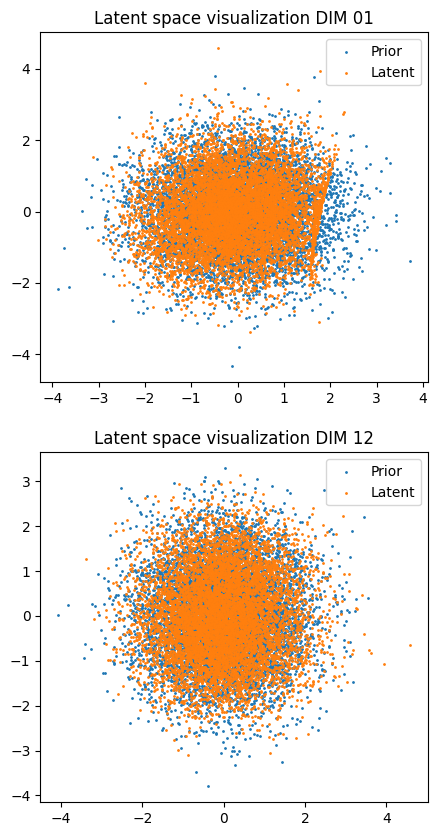

In [22]:
with torch.no_grad():
    latent = fm_reflow.to_prior(data)

plt.figure(figsize=(5,10))
plt.subplot(2,1,1)
plt.scatter(*torch.randn_like(latent)[:,:2].chunk(2,-1),s=1,label='Prior')
plt.scatter(latent[:,0],latent[:,1],s=1,label="Latent")
plt.title("Latent space visualization DIM 01")
plt.legend()
plt.subplot(2,1,2)
plt.scatter(*torch.randn_like(latent)[:,:2].chunk(2,-1),s=1,label='Prior')
plt.scatter(latent[:,1],latent[:,2],s=1,label="Latent")
plt.title("Latent space visualization DIM 12")
plt.legend()

In [23]:
ind = torch.randperm(len(data))[:512]
data_opt,loss = fm_reflow.optimize(data[ind],lr=1,epochs=1)
data_opt=data_opt.detach()*data_std+data_mean
loss

tensor(711.9941, device='cuda:0', grad_fn=<NegBackward0>)

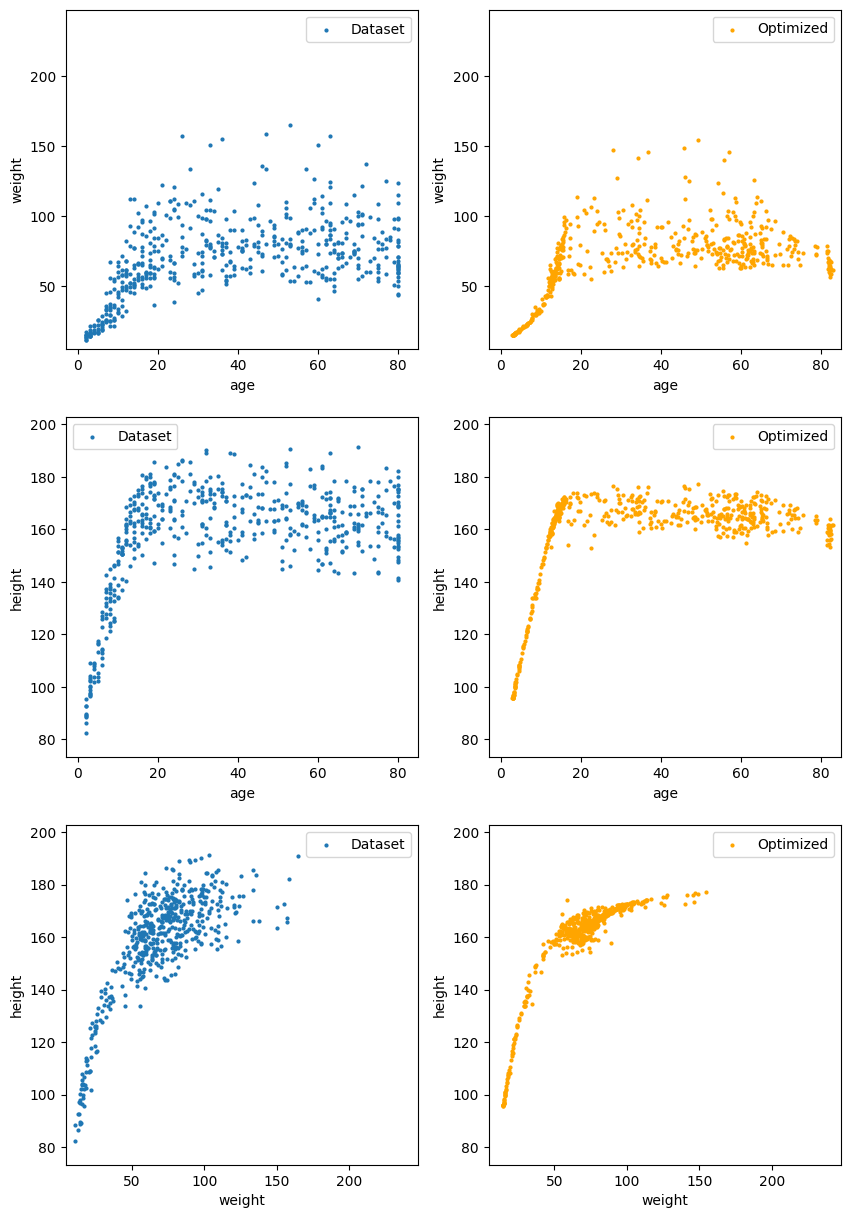

In [24]:

plt.figure(figsize=(10,15))
for i,(indA,indB) in enumerate(permutations):
    X,Y=data_numpy[:,indA],data_numpy[:,indB]
    X_lim = np.quantile(X,0)-5,np.quantile(X,1)+5
    Y_lim = np.quantile(Y,0)-5,np.quantile(Y,1)+5
    plt.subplot(3,2,2*i+1)
    plt.scatter(X[ind],Y[ind],s=4,label="Dataset")
    plt.xlim(*X_lim)
    plt.ylim(*Y_lim)
    plt.xlabel(cols[indA])
    plt.ylabel(cols[indB])
    plt.legend()
    
    plt.subplot(3,2,2*i+2)
    plt.scatter(data_opt[:,indA],data_opt[:,indB],s=4,label="Optimized",c='orange')
    plt.xlim(*X_lim)
    plt.ylim(*Y_lim)
    plt.xlabel(cols[indA])
    plt.ylabel(cols[indB])
    plt.legend()